# Mushroom Classification — Edible vs Poisonous

Binary classification on a Kaggle competition dataset, predicting whether a mushroom is edible (`e`) or poisonous (`p`) from its physical and categorical attributes.

**Workflow:** EDA → missing value & outlier analysis → encoding/scaling pipeline → baseline model comparison (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost) → hyperparameter tuning (Random Forest, XGBoost, LightGBM via `GridSearchCV`) → final LightGBM model → submission.

**Result:** 5-fold stratified cross-validation accuracy of 1.0 across all baseline and tuned models, with the tuned LightGBM pipeline selected as the final model for test predictions.

**Stack:** `pandas`, `scikit-learn`, `XGBoost`, `LightGBM`, `CatBoost`, `matplotlib`/`seaborn`.

> **Note on data:** this notebook was run in the Kaggle environment, so `pd.read_csv(...)` calls point to `/kaggle/input/...`. To reproduce locally, download `train.csv` / `test.csv` from the competition page and update the paths in the "Load Data" cell accordingly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output='pandas')

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
train = pd.read_csv('/kaggle/input/competitions/may-2026kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/may-2026kaggle-assignment-3/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/may-2026kaggle-assignment-3/sample_submission.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (7000, 26)
Test shape: (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


## 2. Data Types

In [3]:
pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'n_unique': train.nunique()
})

,dtype,n_unique
ID,int64,7000
mushroom_id,int64,7000
cap-shape,object,5
cap-surface,object,3
cap-color,object,10
bruises,object,2
number_of_bruises,int64,25
odor,object,8
gill-attachment,object,2
gill-spacing,object,2


In [4]:
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in train.columns if c not in numerical_cols]

print('Numerical columns   :', numerical_cols)
print('Categorical columns :', categorical_cols)

Numerical columns   : ['ID', 'mushroom_id', 'number_of_bruises', 'ring-number']
Categorical columns : ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat', 'class']


## 3. Descriptive Statistics — Numerical Columns

In [5]:
num_feature_cols = ['number_of_bruises', 'ring-number']

desc = train[num_feature_cols].describe().T
desc['median'] = train[num_feature_cols].median()
desc[['min', 'max', 'mean', 'median', 'std']]

,min,max,mean,median,std
number_of_bruises,0.0,24.0,5.459571,0.0,7.723528
ring-number,1.0,2.0,1.080988,1.0,0.272836


## 4. Missing Values

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
odor,3236,46.23
stalk-root,192,2.74
ring-number,36,0.51
ring-type,36,0.51


In [7]:
pd.crosstab(train['odor'].isna(), train['class'])

class,e,p
odor,,
False,544,3220
True,3168,68


Categorical missing values are imputed as an explicit `"missing"` category (missingness in `odor` correlates strongly with class). Numerical `ring-number` is median-imputed inside the pipeline.

In [8]:
cat_cols_all = [c for c in train.columns if c not in ['ID', 'mushroom_id', 'class'] and c not in num_feature_cols]

for c in cat_cols_all:
    train[c] = train[c].fillna('missing').astype(str)
    test[c] = test[c].fillna('missing').astype(str)

## 5. Duplicates

In [9]:
feature_cols_for_dup_check = [c for c in train.columns if c not in ['ID', 'mushroom_id']]
n_dupes = train.duplicated(subset=feature_cols_for_dup_check).sum()
print(f'Duplicate rows: {n_dupes}')

if n_dupes > 0:
    train = train.drop_duplicates(subset=feature_cols_for_dup_check).reset_index(drop=True)
    print('New train shape:', train.shape)

Duplicate rows: 0


## 6. Outliers

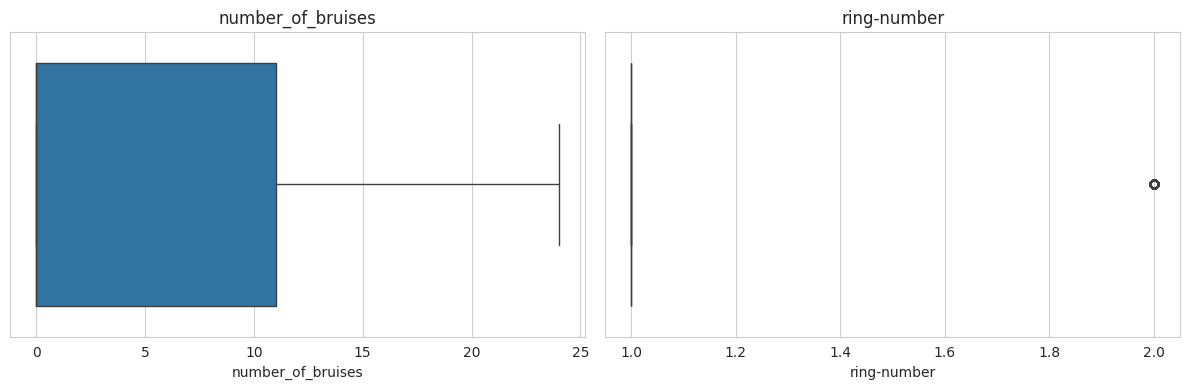

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=train['number_of_bruises'], ax=axes[0])
axes[0].set_title('number_of_bruises')
sns.boxplot(x=train['ring-number'], ax=axes[1])
axes[1].set_title('ring-number')
plt.tight_layout()
plt.show()

In [11]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in num_feature_cols:
    low, high = iqr_bounds(train[col].dropna())
    n_out = ((train[col] < low) | (train[col] > high)).sum()
    print(f'{col:20s} bounds=({low:.2f}, {high:.2f})  range=({train[col].min()}, {train[col].max()})  flagged={n_out}')

number_of_bruises    bounds=(-16.50, 27.50)  range=(0, 24)  flagged=0
ring-number          bounds=(1.00, 1.00)  range=(1.0, 2.0)  flagged=564


Both columns have valid, plausible ranges (bruise counts 0–24, ring counts 1–2). No values are removed.

## 7. Visualizations

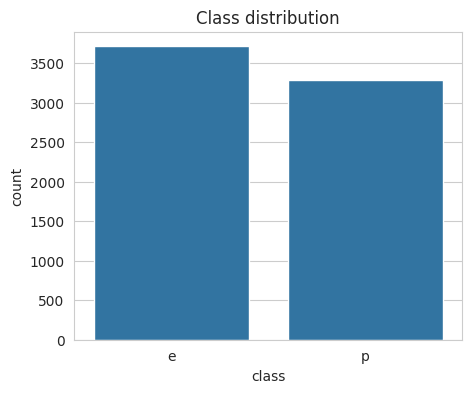

class
e    0.53
p    0.47
Name: proportion, dtype: float64

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(data=train, x='class', order=['e', 'p'])
plt.title('Class distribution')
plt.show()
train['class'].value_counts(normalize=True).round(3)

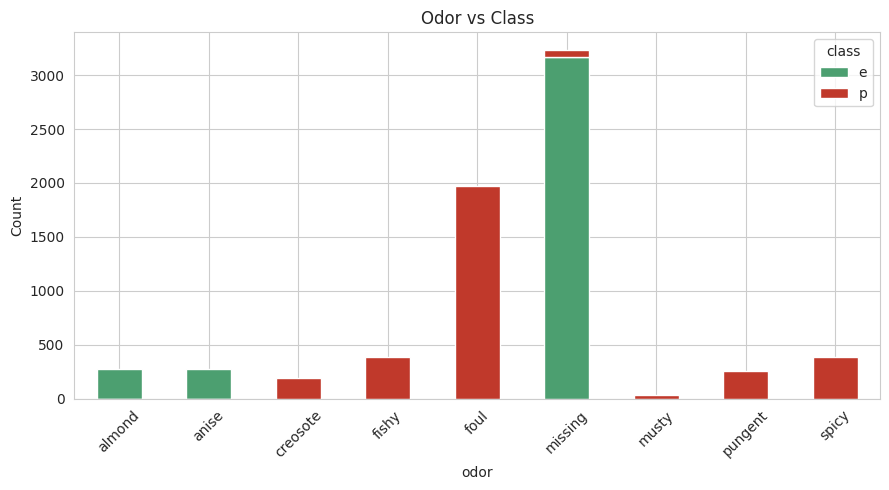

In [13]:
plt.figure(figsize=(9, 5))
odor_ct = pd.crosstab(train['odor'], train['class'])
odor_ct.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#4C9F70', '#C0392B'])
plt.title('Odor vs Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

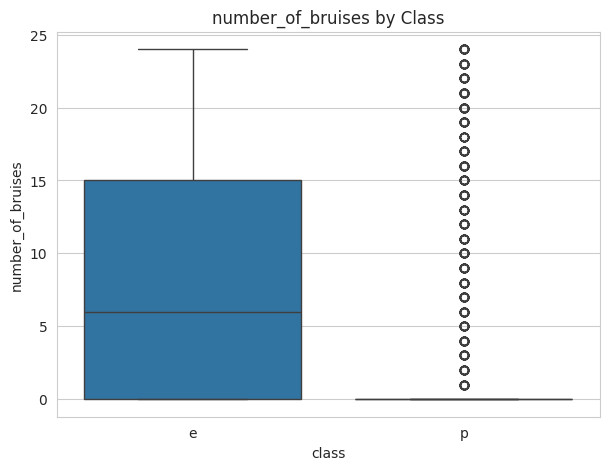

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train, x='class', y='number_of_bruises', order=['e', 'p'])
plt.title('number_of_bruises by Class')
plt.show()

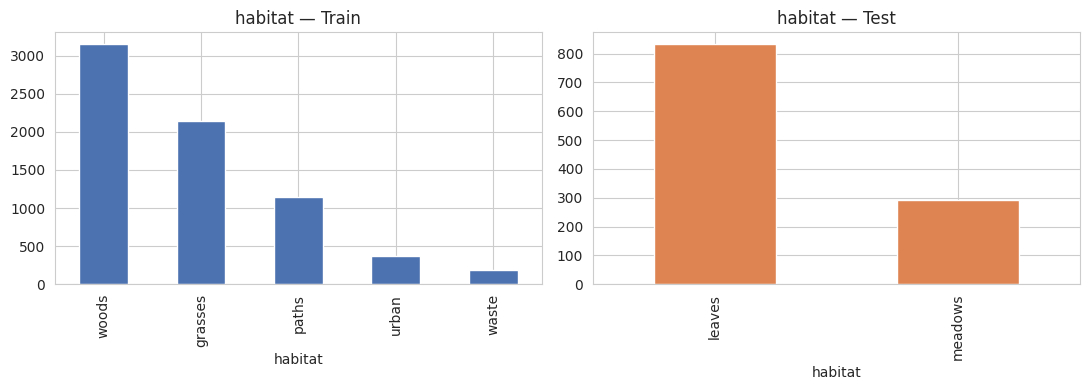

Train habitat: ['grasses', 'paths', 'urban', 'waste', 'woods']
Test habitat : ['leaves', 'meadows']


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train['habitat'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('habitat — Train')
test['habitat'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('habitat — Test')
plt.tight_layout()
plt.show()

print('Train habitat:', sorted(train['habitat'].unique()))
print('Test habitat :', sorted(test['habitat'].unique()))

`habitat` categories in train and test do not overlap at all, so it carries no transferable signal and is dropped from modeling.

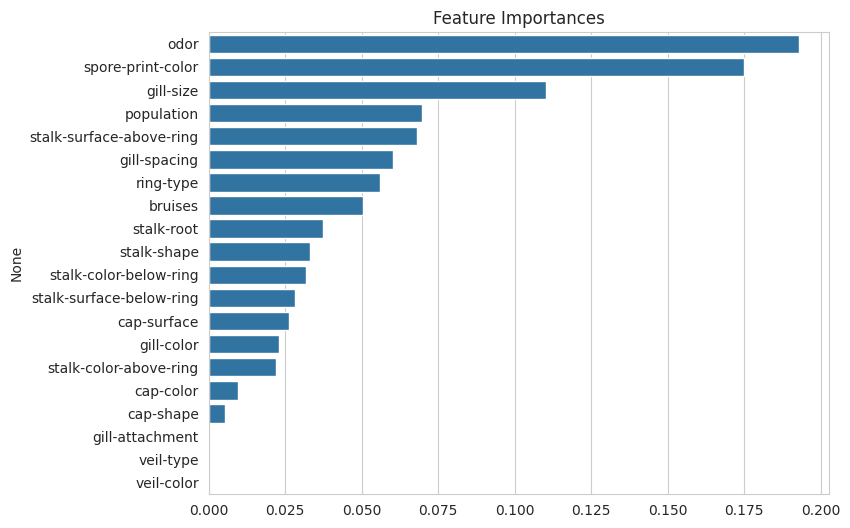

In [16]:
from sklearn.preprocessing import OrdinalEncoder
probe_cols = [c for c in cat_cols_all if c != 'habitat']
oe_probe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_probe = oe_probe.fit_transform(train[probe_cols])
rf_probe = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_probe.fit(X_probe, train['class'].map({'e': 0, 'p': 1}))

imp = pd.Series(rf_probe.feature_importances_, index=probe_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Feature Importances')
plt.show()

## 8. Scaling & Encoding

- `habitat` dropped — zero category overlap between train and test.
- `veil-type` dropped — constant value, zero information.
- Categorical features: `OneHotEncoder(handle_unknown='ignore')`, fit on train only, so unseen test categories map to an all-zero vector instead of a misleading learned code.
- Numerical features: median-imputed and scaled with `StandardScaler` (required for Logistic Regression / KNN; harmless for tree-based models).

In [17]:
FEATURE_DROP_COLS = ['ID', 'mushroom_id', 'class', 'habitat', 'veil-type']
feature_cols = [c for c in train.columns if c not in FEATURE_DROP_COLS]

cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(train[c])]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train[c])]

X = train[feature_cols].copy()
y = train['class'].map({'e': 0, 'p': 1})
X_test_final = test[feature_cols].copy()
test_ids = test['ID']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_cols)
])

## 9. Model Building

In [18]:
candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1),
    'CatBoost': CatBoostClassifier(iterations=300, verbose=False, random_seed=RANDOM_STATE),
}

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_cv_results = {}
for name, model in candidate_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    baseline_cv_results[name] = scores
    print(f'{name:20s} mean CV accuracy = {scores.mean():.5f}')

LogisticRegression   mean CV accuracy = 1.00000
KNN                  mean CV accuracy = 1.00000
DecisionTree         mean CV accuracy = 1.00000
RandomForest         mean CV accuracy = 1.00000
GradientBoosting     mean CV accuracy = 1.00000
XGBoost              mean CV accuracy = 1.00000
LightGBM             mean CV accuracy = 1.00000
CatBoost             mean CV accuracy = 1.00000


## 10. Hyperparameter Tuning

In [20]:
rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2],
}
rf_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=skf, scoring='accuracy', n_jobs=-1)
rf_search.fit(X, y)
print('Best RF params:', rf_search.best_params_)
print('Best RF CV accuracy:', rf_search.best_score_)

Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best RF CV accuracy: 1.0


In [21]:
xgb_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.05, 0.1],
}
xgb_pipe = Pipeline([('pre', preprocessor), ('model', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))])
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, cv=skf, scoring='accuracy', n_jobs=-1)
xgb_search.fit(X, y)
print('Best XGB params:', xgb_search.best_params_)
print('Best XGB CV accuracy:', xgb_search.best_score_)

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best XGB CV accuracy: 1.0


In [22]:
lgbm_grid = {
    'model__n_estimators': [200, 400],
    'model__num_leaves': [15, 31],
    'model__learning_rate': [0.05, 0.1],
}
lgbm_pipe = Pipeline([('pre', preprocessor), ('model', LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1))])
lgbm_search = GridSearchCV(lgbm_pipe, lgbm_grid, cv=skf, scoring='accuracy', n_jobs=-1)
lgbm_search.fit(X, y)
print('Best LightGBM params:', lgbm_search.best_params_)
print('Best LightGBM CV accuracy:', lgbm_search.best_score_)

Best LightGBM params: {'model__learning_rate': 0.05, 'model__n_estimators': 200, 'model__num_leaves': 15}
Best LightGBM CV accuracy: 1.0


## 11. Model Comparison

In [23]:
comparison = pd.DataFrame({
    name: [scores.mean(), scores.std()] for name, scores in baseline_cv_results.items()
}, index=['mean_cv_accuracy', 'std_cv_accuracy']).T.sort_values('mean_cv_accuracy', ascending=False)

comparison.loc['RandomForest (tuned)'] = [rf_search.best_score_, np.nan]
comparison.loc['XGBoost (tuned)'] = [xgb_search.best_score_, np.nan]
comparison.loc['LightGBM (tuned)'] = [lgbm_search.best_score_, np.nan]
comparison = comparison.sort_values('mean_cv_accuracy', ascending=False)
comparison

,mean_cv_accuracy,std_cv_accuracy
LogisticRegression,1.0,0.0
KNN,1.0,0.0
DecisionTree,1.0,0.0
RandomForest,1.0,0.0
GradientBoosting,1.0,0.0
XGBoost,1.0,0.0
LightGBM,1.0,0.0
CatBoost,1.0,0.0
RandomForest (tuned),1.0,NaN
XGBoost (tuned),1.0,NaN


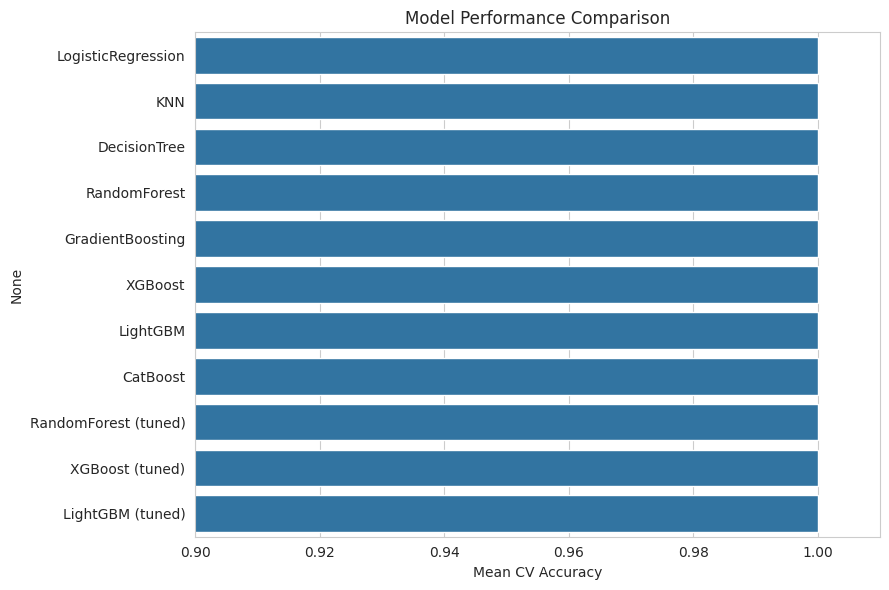

In [24]:
plt.figure(figsize=(9, 6))
sns.barplot(x=comparison['mean_cv_accuracy'], y=comparison.index, orient='h')
plt.xlabel('Mean CV Accuracy')
plt.title('Model Performance Comparison')
plt.xlim(0.9, 1.01)
plt.tight_layout()
plt.show()

## 12. Final Model & Submission

Training accuracy: 1.0
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00      3712
   poisonous       1.00      1.00      1.00      3288

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000



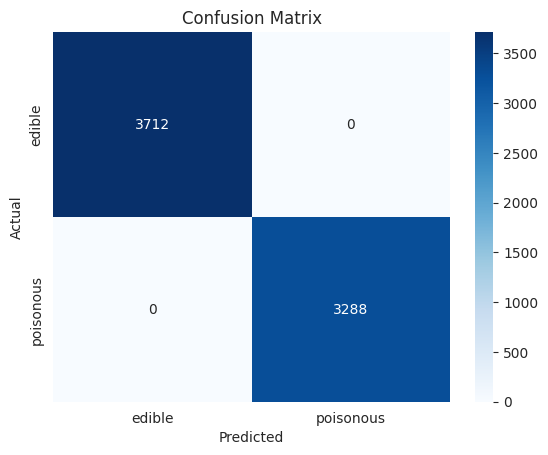

In [25]:
final_model = Pipeline([
    ('pre', preprocessor),
    ('model', LGBMClassifier(**{k.replace('model__', ''): v for k, v in lgbm_search.best_params_.items()},
                              random_state=RANDOM_STATE, verbosity=-1))
])
final_model.fit(X, y)

train_preds = final_model.predict(X)
print('Training accuracy:', accuracy_score(y, train_preds))
print(classification_report(y, train_preds, target_names=['edible', 'poisonous']))

cm = confusion_matrix(y, train_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

In [26]:
test_preds = final_model.predict(X_test_final)
test_pred_labels = pd.Series(test_preds).map({0: 'e', 1: 'p'})

submission = pd.DataFrame({'ID': test_ids, 'class': test_pred_labels})

assert list(submission.columns) == list(sample_submission.columns)
assert submission.shape[0] == sample_submission.shape[0]
assert set(submission['class'].unique()) <= {'e', 'p'}

submission.to_csv('submission.csv', index=False)
print('submission.csv written:', submission.shape)
submission['class'].value_counts()

submission.csv written: (1124, 2)


class
p    620
e    504
Name: count, dtype: int64